 Load cleaned data

In [3]:
import pandas as pd

df = pd.read_csv("/Users/amirah/Desktop/NLP_f/final_dataset.csv")

print(df.shape)
df.head()

(16257, 2)


,clean_text,label
0,حقوق المراه,1
1,RT حقوق المراه في الاسلام,1
2,RT Retweted لجنه التنميه بشبرا \n \n ما زال ال...,1
3,RT حقوق المراه التي تضمنها لها وزاره العدل,1
4,RT ولي امر الزوجه او ولي الزوجه او ولي المراه ...,1


Split

In [4]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']

# 80% train / 20% (test + val)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Temp:", X_temp.shape)

Train: (13005,)
Temp: (3252,)


In [5]:
# نقسم الـ 20% إلى 10% test و 10% val
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,   # نص الـ 20% → 10% و 10%
    random_state=42,
    stratify=y_temp
)

print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Validation: (1626,)
Test: (1626,)


اتأكد من التوزيع

In [6]:
print("\nTrain distribution:")
print(y_train.value_counts())

print("\nValidation distribution:")
print(y_val.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())


Train distribution:
label
1    6286
0    5036
2    1683
Name: count, dtype: int64

Validation distribution:
label
1    786
0    629
2    211
Name: count, dtype: int64

Test distribution:
label
1    786
0    630
2    210
Name: count, dtype: int64


رسم توزيع الـ Train

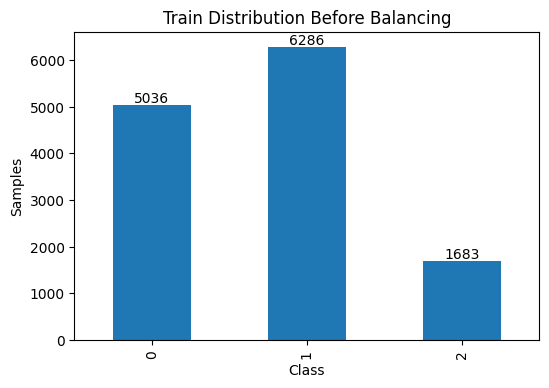

In [13]:
plt.figure(figsize=(6,4))

y_train.value_counts().sort_index().plot(kind='bar')

plt.title("Train Distribution Before Balancing")
plt.xlabel("Class")
plt.ylabel("Samples")

for i, v in enumerate(y_train.value_counts().sort_index()):
    plt.text(i, v + 50, str(v), ha='center')

plt.show()

بالنس بطريقه Hybrid

Undersample + Oversample

In [10]:
from sklearn.utils import resample
import pandas as pd

train_df = pd.DataFrame({
    'text': X_train,
    'label': y_train
})

# تقسيم حسب الكلاسات
df_0 = train_df[train_df['label'] == 0]
df_1 = train_df[train_df['label'] == 1]
df_2 = train_df[train_df['label'] == 2]

# نحدد العدد )
target = int((len(df_0) + len(df_1) + len(df_2)) / 3)

# downsample للكلاسات الكبيرة
df_0_bal = resample(df_0, replace=False, n_samples=target, random_state=42)
df_1_bal = resample(df_1, replace=False, n_samples=target, random_state=42)

# upsample للكلاس الصغير
df_2_bal = resample(df_2, replace=True, n_samples=target, random_state=42)

# دمج
balanced_df = pd.concat([df_0_bal, df_1_bal, df_2_bal])

# shuffle
balanced_df = balanced_df.sample(frac=1, random_state=42)

X_train_bal = balanced_df['text']
y_train_bal = balanced_df['label']

print(y_train_bal.value_counts())

label
2    4335
1    4335
0    4335
Name: count, dtype: int64


رسم بعد الـ balance

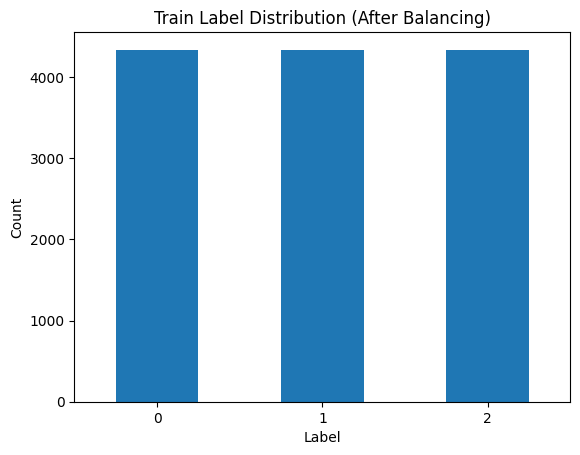

In [11]:
y_train_bal.value_counts().sort_index().plot(kind='bar')

plt.title("Train Label Distribution (After Balancing)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

حفظ البيانات بعد التقسيم

In [14]:
import pandas as pd

train_df = pd.DataFrame({
    'clean_text': X_train,
    'label': y_train
})

val_df = pd.DataFrame({
    'clean_text': X_val,
    'label': y_val
})

test_df = pd.DataFrame({
    'clean_text': X_test,
    'label': y_test
})

train_df.to_csv("new_train.csv", index=False)
val_df.to_csv("new_val.csv", index=False)
test_df.to_csv("new_test.csv", index=False)

print("Saved train / val / test ")

Saved train / val / test 


نحفظ train بعد الـ balance

In [15]:
train_bal_df = pd.DataFrame({
    'clean_text': X_train_bal,
    'label': y_train_bal
})

train_bal_df.to_csv("new_train_balanced.csv", index=False)

print("Saved balanced train ")

Saved balanced train 
